In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [3]:
np.random.seed(42)
sns.set_style("whitegrid")

### Task 1: Bias Diagnosis — Case Studies

For each of the following scenarios, identify the **type of bias** present (selection bias, survivorship bias, measurement bias, response bias, or another relevant type), explain **how** it distorts the conclusions, and suggest **one concrete fix**.

**Scenario A — App Review Analysis:**
A product team analyzes their app's reviews on the App Store to understand user satisfaction. The average rating is 4.3/5, so they conclude that most users are happy. They plan to reduce investment in customer support.

**Scenario B — Startup Success Study:**
A business school studies 200 successful tech startups (all founded in the last 10 years and still operating) to identify common traits that predict startup success. They find that 80% had a pivot in their first two years and conclude that pivoting is a key success strategy.

**Scenario C — Health Survey:**
A health organization sends a voluntary online survey to 50,000 email subscribers asking about exercise habits and health outcomes. The survey receives 5,000 responses (10% response rate). Results show that respondents exercise an average of 5 hours per week and have excellent self-reported health.

**Scenario D — Salary Benchmarking:**
A recruiting platform publishes average salaries by job title based on user-submitted salary data. The platform is popular among tech workers in large cities. A company in a small town uses this data to set their salary bands.

Write your analysis in markdown cells — no code required for this task. Aim for 3–5 sentences per scenario.

## Scenario A — App Review Analysis

**Bias Type:** Selection Bias  

**Explanation:**  
The team only considers **App Store reviews** to calculate the average rating of 4.3/5. This is **selection bias** because the sample does not represent the entire user population:  
- Some users use Android devices and leave reviews on **Google Play**, which are not included.  
- Some users never leave any reviews (e.g., elderly users or less tech-savvy users).  
- As a result, the analysis overestimates overall user satisfaction.  

**Impact:**  
Decisions based only on App Store reviews—such as reducing investment in customer support—may harm overall user satisfaction because silent or underserved users are ignored.  

**Concrete Fix:**  
- Conduct a **survey** via email or in-app messages to collect feedback from a random sample of all users.  
- Include users from different platforms and demographics to ensure the sample represents the full population.

## Scenario B — Startup Success Study

**Bias Type:** Survivorship Bias  

**Explanation:**  
The study only looks at **successful tech startups** founded in the last 10 years that are still operating. This creates **survivorship bias** because:  
- Failed or less successful startups are **excluded** from the analysis.  
- The findings (e.g., 80% pivoted in the first two years) **overestimate the importance of pivoting** as a success strategy.  
- The sample does not represent all startups, only the "survivors," so conclusions about general startup success are distorted.  

**Impact:**  
Relying solely on this data may mislead entrepreneurs into thinking pivoting guarantees success, ignoring the many startups that pivoted but still failed.  

**Concrete Fix:**  
- Include a **broader sample** of startups, including failed or less successful ones.  
- Analyze patterns across both successful and failed startups to get a **more realistic picture** of factors influencing success.

## Scenario C — Health Survey

**Bias Type:** Response Bias  

**Explanation:**  
The organization sends a **voluntary online survey** to 50,000 email subscribers, but only **5,000 respond** (10% response rate). This creates **response bias** because:  
- Respondents are likely **health-conscious or more active**, while less healthy or busier individuals may not respond.  
- The results (average 5 hours of exercise per week and excellent self-reported health) **do not accurately represent the entire population**.  

**Impact:**  
Decisions or conclusions based solely on these responses may **overestimate the general population’s health and activity levels**.  

**Concrete Fix:**  
- Apply **weighting techniques** to account for non-respondents.  
- Or conduct a **random sample survey** to ensure the sample represents the full population.

## Scenario D — Salary Benchmarking

**Bias Type:** Measurement Bias  

**Explanation:**  
The platform publishes **average salaries based on user-submitted data**. This can introduce **measurement bias** because:  
- Salaries in large cities may be higher, skewing the averages.  
- Users may not report their salaries accurately, intentionally or unintentionally.  
- Companies in small towns relying on this data may **make incorrect salary decisions**.  

**Impact:**  
Salary bands may be set too high or too low relative to the actual local market, leading to **hiring challenges or unfair compensation**.  

**Concrete Fix:**  
- Segment salary data by **geography and industry** to make it more representative.  
- Apply **data cleaning and verification methods** to improve accuracy.

Population Parameters (Ground Truth):
{'mean_age': np.float64(40.02052), 'mean_income': np.float64(60675.2692884), 'mean_satisfaction': np.float64(3.674473), 'region_proportions': region
Urban       0.59927
Suburban    0.25075
Rural       0.14998
Name: proportion, dtype: float64}

Population Summary:
                 age         income   satisfaction
count  100000.000000  100000.000000  100000.000000
mean       40.020520   60675.269288       3.674473
std        14.024143   27898.682690       2.169895
min        18.000000   15000.000000       1.000000
25%        29.000000   39781.697500       1.800000
50%        40.000000   59568.800000       3.400000
75%        50.000000   79651.925000       5.100000
max        85.000000  181019.500000      10.000000


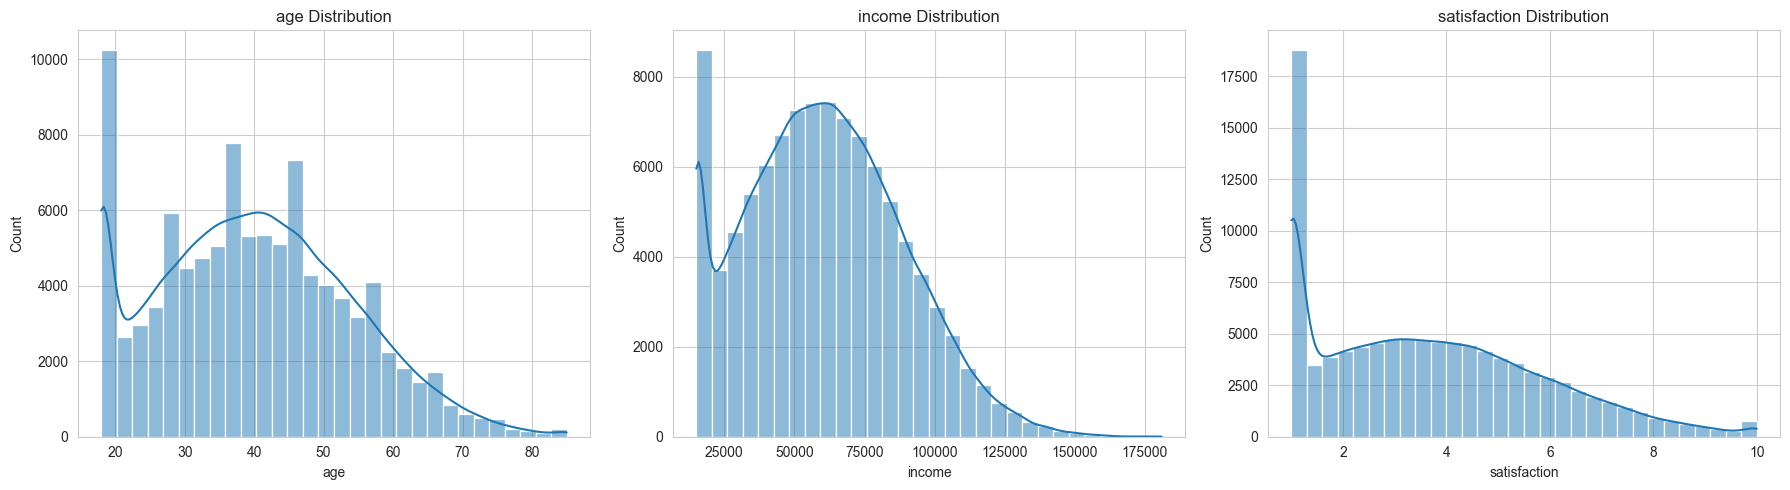

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


population_size = 100_000


np.random.seed(42)  
age = np.random.normal(loc=40, scale=15, size=population_size)
age = np.clip(age, 18, 85).astype(int)

noise = np.random.normal(0, 20000, population_size)  
income = 1500 * age + noise
income = np.clip(income, 15_000, 250_000).round(2)

satisfaction_noise = np.random.normal(0, 2, population_size)  
satisfaction = 1 + 9 * ((income - income.min()) / (income.max() - income.min())) + satisfaction_noise
satisfaction = np.clip(satisfaction, 1, 10).round(1)


regions = np.random.choice(
    ['Urban', 'Suburban', 'Rural'],
    size=population_size,
    p=[0.6, 0.25, 0.15]
)


population = pd.DataFrame({
    'age': age,
    'income': income,
    'satisfaction': satisfaction,
    'region': regions
})


population_params = {
    'mean_age': population['age'].mean(),
    'mean_income': population['income'].mean(),
    'mean_satisfaction': population['satisfaction'].mean(),
    'region_proportions': population['region'].value_counts(normalize=True)
}

print("Population Parameters (Ground Truth):")
print(population_params)


print("\nPopulation Summary:")
print(population.describe())


numeric_vars = ['age', 'income', 'satisfaction']
fig, axes = plt.subplots(1, 3, figsize=(18,5))
for i, var in enumerate(numeric_vars):
    sns.histplot(population[var], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'{var} Distribution')
plt.tight_layout()
plt.show()

### Task 3: Biased vs. Unbiased Sampling

Draw samples from your population using three different strategies and compare how well each recovers the true population parameters.

1. **Simple random sample** (n = 200): every individual has an equal chance of being selected.
2. **Biased sample — Urban only** (n = 200): only sample from individuals in the "Urban" region.
3. **Biased sample — High-income filter** (n = 200): only sample from individuals with income above the population median.

For each sample:
- Compute mean age, mean income, and mean satisfaction.
- Display the results alongside the true population parameters in a comparison table.
- Create overlapping KDE plots (sample vs. population) for income and satisfaction.

Now, repeat each sampling strategy **1,000 times** and collect the sample means:
- Plot the **sampling distribution of the mean income** for each strategy (three histograms, side by side).
- Mark the true population mean on each histogram.

**Guiding question:** Which sampling strategies produce biased estimates? How can you tell from the sampling distributions?

Comparison Table:
             Mean Age   Mean Income  Mean Satisfaction
SRS          40.29000  62424.166900           3.723500
Urban Only   39.70000  60492.592800           3.768500
High Income  49.41500  85726.042300           4.659500
Population   40.02052  60675.269288           3.674473


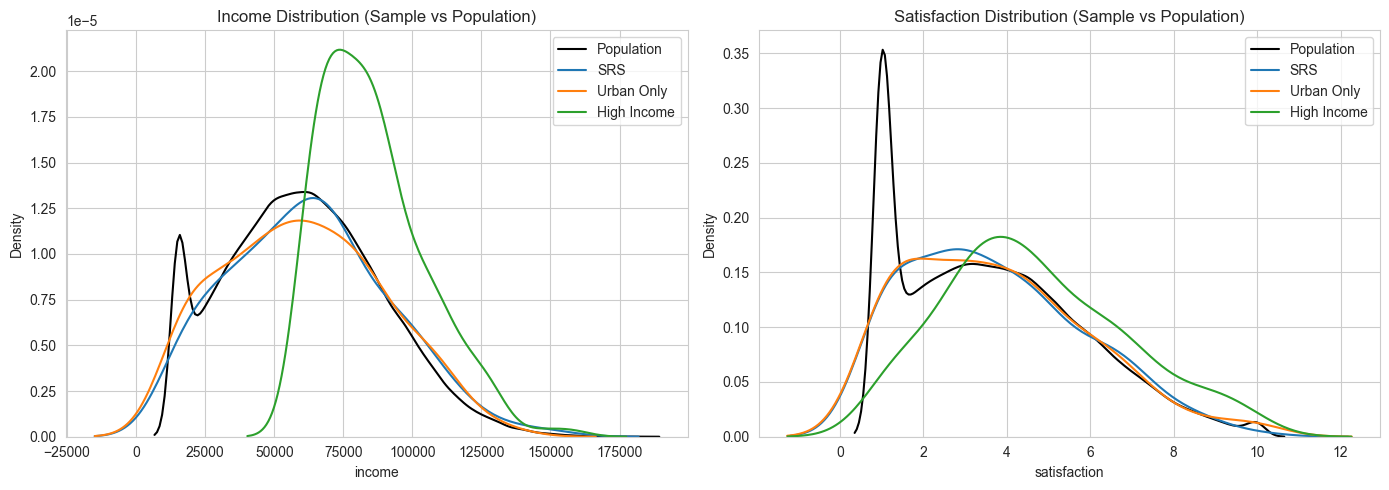

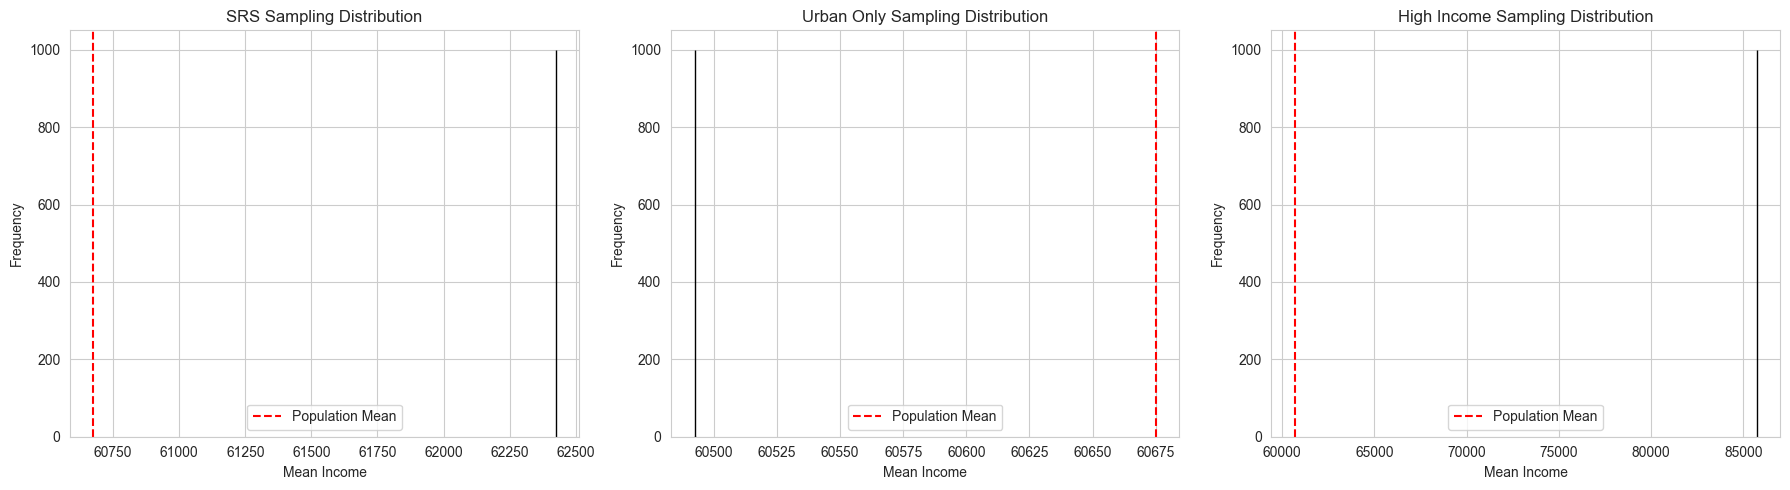

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

def simple_random_sample(df, n=200):
    return df.sample(n=n, random_state=42)

def urban_only_sample(df, n=200):
    return df[df['region'] == 'Urban'].sample(n=n, random_state=42)

def high_income_sample(df, n=200):
    median_income = df['income'].median()
    return df[df['income'] > median_income].sample(n=n, random_state=42)


samples = {
    'SRS': simple_random_sample(population),
    'Urban Only': urban_only_sample(population),
    'High Income': high_income_sample(population)
}

comparison = pd.DataFrame(columns=['Mean Age', 'Mean Income', 'Mean Satisfaction'])
for name, sample in samples.items():
    comparison.loc[name] = [
        sample['age'].mean(),
        sample['income'].mean(),
        sample['satisfaction'].mean()
    ]


comparison.loc['Population'] = [
    population['age'].mean(),
    population['income'].mean(),
    population['satisfaction'].mean()
]

print("Comparison Table:")
print(comparison)


fig, axes = plt.subplots(1,2, figsize=(14,5))
for var, ax in zip(['income', 'satisfaction'], axes):
    sns.kdeplot(population[var], label='Population', ax=ax, color='black')
    for name, sample in samples.items():
        sns.kdeplot(sample[var], label=name, ax=ax)
    ax.set_title(f'{var.capitalize()} Distribution (Sample vs Population)')
    ax.legend()
plt.tight_layout()
plt.show()


n_iter = 1000
sample_means = {'SRS':[], 'Urban Only':[], 'High Income':[]}

for _ in range(n_iter):
    sample_means['SRS'].append(simple_random_sample(population)['income'].mean())
    sample_means['Urban Only'].append(urban_only_sample(population)['income'].mean())
    sample_means['High Income'].append(high_income_sample(population)['income'].mean())


fig, axes = plt.subplots(1,3, figsize=(18,5))
for ax, key in zip(axes, sample_means.keys()):
    ax.hist(sample_means[key], bins=30, color='skyblue', edgecolor='black')
    ax.axvline(population['income'].mean(), color='red', linestyle='--', label='Population Mean')
    ax.set_title(f'{key} Sampling Distribution')
    ax.set_xlabel('Mean Income')
    ax.set_ylabel('Frequency')
    ax.legend()
plt.tight_layout()
plt.show()

## Guiding Question — Biased vs. Unbiased Sampling

**Biased Sampling Strategies:**  
- Urban-only sample  
- High-income sample  

**Unbiased Sampling Strategy:**  
- Simple Random Sample (SRS)  

**Explanation:**  
- Urban-only and high-income samples **systematically exclude parts of the population**:  
  - Urban-only ignores Suburban and Rural individuals.  
  - High-income ignores lower-income individuals.  
- From the **sampling distributions**, biased strategies show **sample means consistently shifted** away from the true population mean.  
- SRS sample means are **centered around the true population mean**, indicating no systematic bias.